In [40]:
!pip install statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 43.9 MB/s eta 0:00:00:00:01


In [1]:
import os
import pandas as pd

# Define input folder
input_folder = "Attribution Scores_14B"

# Initialize list to collect statistics
stats_list = []

# Loop over all CSVs in the folder
for filename in os.listdir(input_folder):
    if filename.endswith(".csv") and filename.startswith("MedBullets_df_op4_Q"):
        filepath = os.path.join(input_folder, filename)
        
        try:
            df = pd.read_csv(filepath)

            # Check if necessary columns exist
            if "Score" in df.columns and "Extracted_Answer" in df.columns:
                mean_score = df["Score"].mean()
                std_score = df["Score"].std()
                extracted_answer = df["Extracted_Answer"].dropna().astype(str).iloc[0] if not df["Extracted_Answer"].dropna().empty else None

                stats_list.append({
                    "QA_ID": filename.replace(".csv", ""),
                    "Mean_Score": mean_score,
                    "Std_Score": std_score,
                    "Extracted_Answer": extracted_answer
                })
            else:
                print(f"⚠️ Skipped {filename} (missing 'Score' or 'Extracted_Answer' column)")

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

# Create summary DataFrame
stats_df = pd.DataFrame(stats_list)

# Display the first few rows
stats_df.head(30)
print(len(stats_df))

298


In [2]:
# Add new columns: 1 std above and below the mean
stats_df["Upper_Threshold"] = stats_df["Mean_Score"] + stats_df["Std_Score"]
stats_df["Lower_Threshold"] = stats_df["Mean_Score"] - stats_df["Std_Score"]

# Display updated DataFrame
stats_df.head()


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold
0,MedBullets_df_op4_Q273,18.894300,16.240688,C,35.134988,2.653612
1,MedBullets_df_op4_Q164,18.218318,19.395505,D,37.613823,-1.177188
2,MedBullets_df_op4_Q118,5.417953,8.411724,None,13.829677,-2.993772
3,MedBullets_df_op4_Q56,7.302810,7.798768,A,15.101578,-0.495958
4,MedBullets_df_op4_Q87,14.449656,16.121770,A,30.571426,-1.672114


In [3]:
import os
import pandas as pd

# Initialize relevance columns with zero
stats_df["Highly Relevant"] = 0
stats_df["Low Relevant"] = 0
stats_df["Irrelevant"] = 0

# Define input directory
input_folder = "Attribution Scores"

# Process each QA file and compute relevance categories
for i, row in stats_df.iterrows():
    qa_id = row["QA_ID"]
    file_path = os.path.join(input_folder, f"{qa_id}.csv")

    try:
        df = pd.read_csv(file_path)

        if "Score" in df.columns:
            scores = df["Score"]

            # Count relevance categories based on thresholds
            high_count = (scores > row["Upper_Threshold"]).sum()
            low_count = ((scores >= row["Lower_Threshold"]) & (scores <= row["Upper_Threshold"]) & (scores != 0)).sum()
            zero_count = (scores == 0).sum()

            # Update stats_df with raw counts
            stats_df.at[i, "Highly Relevant"] = high_count
            stats_df.at[i, "Low Relevant"] = low_count
            stats_df.at[i, "Irrelevant"] = zero_count
        else:
            print(f"⚠️ Skipped {qa_id}.csv — 'Score' column not found.")

    except Exception as e:
        print(f"❌ Error processing {qa_id}.csv: {e}")

# Normalize counts into proportions
relevance_cols = ["Highly Relevant", "Low Relevant", "Irrelevant"]
relevance_totals = stats_df[relevance_cols].sum(axis=1)

for col in relevance_cols:
    stats_df[col] = stats_df[col] / relevance_totals

# Preview results
stats_df.head(5)


❌ Error processing MedBullets_df_op4_Q273.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q273.csv'
❌ Error processing MedBullets_df_op4_Q164.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q164.csv'
❌ Error processing MedBullets_df_op4_Q118.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q118.csv'
❌ Error processing MedBullets_df_op4_Q56.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q56.csv'
❌ Error processing MedBullets_df_op4_Q87.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q87.csv'
❌ Error processing MedBullets_df_op4_Q208.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q208.csv'
❌ Error processing MedBullets_df_op4_Q51.csv: [Errno 2] No such file or directory: 'Attribution Scores/MedBullets_df_op4_Q51.csv'
❌ Error processing MedBullets_df_op4_Q80.csv: [Errno 2] No such file or directory:

,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant
0,MedBullets_df_op4_Q273,18.894300,16.240688,C,35.134988,2.653612,NaN,NaN,NaN
1,MedBullets_df_op4_Q164,18.218318,19.395505,D,37.613823,-1.177188,NaN,NaN,NaN
2,MedBullets_df_op4_Q118,5.417953,8.411724,None,13.829677,-2.993772,NaN,NaN,NaN
3,MedBullets_df_op4_Q56,7.302810,7.798768,A,15.101578,-0.495958,NaN,NaN,NaN
4,MedBullets_df_op4_Q87,14.449656,16.121770,A,30.571426,-1.672114,NaN,NaN,NaN


## Measure Statistical Significance

In [82]:
# Reshape the DataFrame for analysis
df_long = stats_df[["Highly Relevant", "Low Relevant", "Irrelevant"]].reset_index().melt(
    id_vars="index", 
    var_name="RelevanceCategory", 
    value_name="Proportion"
)
df_long = df_long.rename(columns={"index": "Subject"})

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the repeated-measures ANOVA model
model = ols("Proportion ~ C(RelevanceCategory) + C(Subject)", data=df_long).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_long["Proportion"],
                          groups=df_long["RelevanceCategory"],
                          alpha=0.05)
print(tukey)


                            sum_sq     df             F        PR(>F)
C(RelevanceCategory)  3.783318e+00    2.0  2.677205e+01  7.371886e-12
C(Subject)            3.840956e-28  297.0  1.830297e-29  1.000000e+00
Residual              4.197085e+01  594.0           NaN           NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1        group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------
Highly Relevant   Irrelevant  -0.1201    0.0 -0.1618 -0.0783   True
Highly Relevant Low Relevant   0.0307 0.1955  -0.011  0.0725  False
     Irrelevant Low Relevant   0.1508    0.0   0.109  0.1925   True
-------------------------------------------------------------------


In [4]:
std_score = stats_df["Mean_Score"].std()
print(f"Standard Deviation of Mean_Score: {std_score}")

mean_score=stats_df["Mean_Score"].mean()
print(f"Mean of Mean_Score: {mean_score}")


Standard Deviation of Mean_Score: 9.821621270080218
Mean of Mean_Score: 18.365388928790573


/tmp/ipykernel_893057/800718107.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)


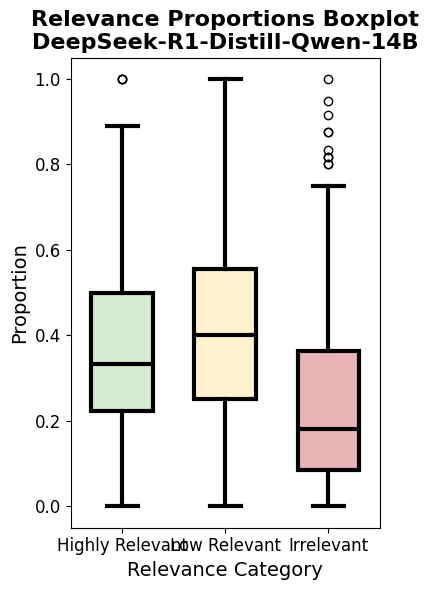

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

# Use your real stats_df here
# Example mock data:
# stats_df = pd.read_csv("your_data.csv")

# HEX colors sampled from your image
color_high = "#d9ead3"        # green for Highly Relevant
color_low = "#fff2cc"         # yellow for Low Relevant
color_irrel = "#e8b4b8"       # red-pink for Irrelevant

# Prepare data
data = [
    stats_df["Highly Relevant"].dropna(),
    stats_df["Low Relevant"].dropna(),
    stats_df["Irrelevant"].dropna()
]

labels = ["Highly Relevant", "Low Relevant", "Irrelevant"]
colors = [color_high, color_low, color_irrel]

# Create plot
fig, ax = plt.subplots(figsize=(4, 6))
bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)

# Set custom facecolors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_linewidth(3)

# Style other elements
for whisker in bp['whiskers']:
    whisker.set_linewidth(3)
for cap in bp['caps']:
    cap.set_linewidth(3)
for median in bp['medians']:
    median.set_linewidth(3)
    median.set_color("black")

# Labels and layout
ax.set_title("Relevance Proportions Boxplot\nDeepSeek-R1-Distill-Qwen-14B", fontsize=16, weight='bold')
ax.set_ylabel("Proportion", fontsize=14)
ax.set_xlabel("Relevance Category", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("qwen14b_relevance_boxplot_fixed.pdf", dpi=300)
plt.show()


## Compare the Results

In [90]:
# Load the medbullets ground truth file
truth_df = pd.read_csv("medbullets_4o_reasoning_results.csv")

# Strip and upper-case for reliable comparison
truth_df["answer_idx"] = truth_df["answer_idx"].astype(str).str.strip().str.upper()
stats_df["Extracted_Answer"] = stats_df["Extracted_Answer"].astype(str).str.strip().str.upper()

# Extract numeric index from QA_ID
stats_df["QA_Index"] = stats_df["QA_ID"].str.extract(r"Q(\d+)", expand=False).astype(int) - 1  # 0-based indexing

# Map ground truth answer
stats_df["Ground_Truth_Answer"] = stats_df["QA_Index"].map(truth_df["answer_idx"])

# Mark match status (will still include 'NONE' for now)
stats_df["Answer_Match"] = stats_df["Extracted_Answer"] == stats_df["Ground_Truth_Answer"]

# Exclude rows where Extracted_Answer is "NONE" from accuracy calculation
valid_mask = stats_df["Extracted_Answer"].str.upper() != "NONE"
valid_answers = stats_df[valid_mask]
excluded_count = len(stats_df) - len(valid_answers)

# Calculate and print accuracy
accuracy = (valid_answers["Extracted_Answer"] == valid_answers["Ground_Truth_Answer"]).mean()
print(f"Accuracy (excluding 'NONE'): {accuracy * 100:.1f}%")
print(f"Excluded {excluded_count} rows with 'Extracted_Answer' as 'NONE'.")

# Preview mismatches (optional)
mismatches = valid_answers[valid_answers["Answer_Match"] == False]

# Sort by QA number
stats_df_sorted = stats_df.sort_values("QA_Index").reset_index(drop=True)

# Display top rows
stats_df_sorted.head(5)


Accuracy (excluding 'NONE'): 24.5%
Excluded 21 rows with 'Extracted_Answer' as 'NONE'.


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant,QA_Index,Ground_Truth_Answer,Answer_Match
0,MedBullets_df_op4_Q1,0.000000,0.000000,B,0.000000,0.000000,0.000000,0.000000,1.000000,0,C,False
1,MedBullets_df_op4_Q2,31.927486,21.444824,C,53.372310,10.482662,0.222222,0.777778,0.000000,1,B,False
2,MedBullets_df_op4_Q3,13.464284,22.675431,C,36.139715,-9.211147,0.500000,0.125000,0.375000,2,A,False
3,MedBullets_df_op4_Q4,26.083098,24.010467,C,50.093566,2.072631,0.166667,0.833333,0.000000,3,D,False
4,MedBullets_df_op4_Q5,11.955319,23.860514,NONE,35.815832,-11.905195,0.363636,0.454545,0.181818,4,A,False


In [91]:
stats_df_sorted.to_csv("14B Results.csv", index=False)